In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    !git pull
    
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils._raised_cosine_basis import makeRaisedCosBasis
# from utils.load_matlab import load_mat_v73, flatten_cell
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d
import utils
from utils import *
import seaborn as sns
sns.set_context("poster")
plt.rcParams['figure.dpi'] = 100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: False


## Load Data

In [2]:
## Training data
data        = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_nr.npz", allow_pickle=True)
stim_mat        = data["stim"]
spk_t      = data['spk_times']
spk_train_mat   = data['spk_train']
V_train  = data['raw_traces'] # shape (N_train, T_v) 

## Test Data
data_test   = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz", allow_pickle=True)
stim_rs        = data_test["stim"]
spktimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)
psth           = np.mean(spk_t_test, axis=0)

cell_type = "OFF transient MeRF"

In [3]:
### MODEL PARAMS
dt = 1e-4
dt_stim = 1 / 60.0
trial_dur_s = stim_mat.shape[1] * dt_stim
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

##stim basis params
nInh = 1
nExc = 1

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02

In [4]:
# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

stimulus, spk_train = preprocess_split(stim_mat, spk_t, 
                                       presamples=presamples, postsamples=postsamples, 
                                       n_trials=len(spk_t), 
                                       T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)
stimulus_test, spk_test = preprocess_split(stim_rs, spktimes_rs, 
                                           presamples=presamples, postsamples=postsamples, 
                                           n_trials=len(spktimes_rs), 
                                        T_cell_full=T_cell_full, dt_stim=dt_stim, dt=dt, bin_edges_s=bin_edges_s)

print('train:', stimulus.shape, spk_train.shape, 'mean rate (Hz):', spk_train.mean() / dt)
print('test :', stimulus_test.shape, spk_test.shape, 'mean rate (Hz):', spk_test.mean() / dt)


train: (11, 100000) (11, 100000) mean rate (Hz): 6.9818181818181815
test : (6, 100000) (6, 100000) mean rate (Hz): 6.7


/home/guardomayas/NUIN/CBEM_pytorch/utils/data_preprocessing.py:104: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


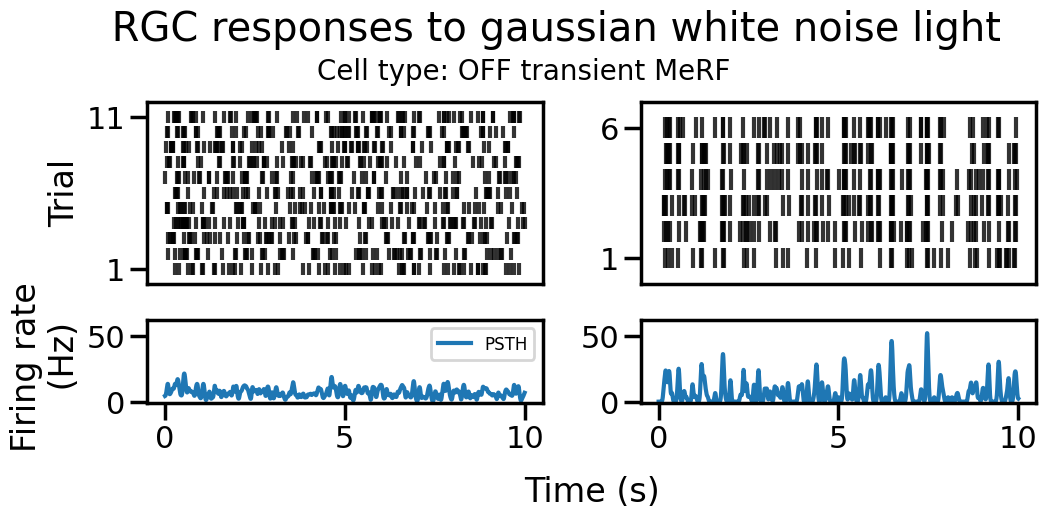

In [5]:
spkTimes_bins = [np.where(spk_train[trial] > 0)[0] for trial in range(spk_train.shape[0])] # spk_train: [B, T]

spkTimes_by_trial = [idx * dt for idx in spkTimes_bins] # in ms (since dt_ms is ms/bin)

spk_idx_trials = [
    torch.as_tensor(np.where(spk_train[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_train.shape[0])
]

spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]

sigma = max(1, int(0.02 / dt)) #psth smoothing window

spk_t_sec_test = [idx.detach().cpu().numpy() * dt for idx in spk_idx_test]  # list of arrays (sec)
spk_t_s_train  = [idx.detach().cpu().numpy() * dt for idx in spk_idx_trials]


t_sec = np.arange(spk_test.shape[1]) * dt

B, T = spk_test.shape
B_tr, _ = spk_train.shape
t_sec = np.arange(T) * dt

psth_hz_smooth = gaussian_filter1d(spk_test.mean(axis=0) / dt, sigma=sigma)  # 20 ms
psth_train = gaussian_filter1d(spk_train.mean(axis=0) / dt, sigma=sigma)

fig = plot_responses(spk_t_s_train, 
                   spk_t_sec_test, 
                   psth_hz_smooth, 
                   psth_train,
                   cell_type, 
                   dt, B, B_tr, T
                   )


# Design matrix

In [8]:
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float64, device=device)

# stimulus_t: [B, T]
# basis_t: [L, P]
X_trials = [
    convolveStimulusWithBasis_torch(stimulus_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_t.shape[0])
]
X_full = torch.stack(X_trials, dim=0)  # [B,T,D]
print('X_full:', X_full.shape)
print("#"*50)
print("Training linear input model (CB_GLM)")
linmodel = CBEM_linear(binsize_s=dt).to(device)

cbem_lin, (steps_hist, loss_hist) = train_cbem_trials(
    linmodel,
    X_cond=X_full,
    basis_matrix= B_orth_t,
    spkTimes_bins=spk_idx_trials,
    lr=1e-1,
    conductance_penalty=None,
    n_steps=200,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None)


X_full: torch.Size([11, 100000, 11])
##################################################
Training linear model
[train] Initialized B_cond with zeros with shape (11, 1)
model device: cuda:0
step     1 | loss 635.565 | data 635.565 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 1.408 Hz
step   100 | loss 527.054 | data 527.054 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 7.081 Hz
step   200 | loss 527.054 | data 527.054 | pen_w 0.000 | pen_sm 0.000000e+00 | mean rate 7.080 Hz


In [9]:
B_cond_lin = cbem_lin.B_cond.detach().cpu()
w_lin = B_cond_lin[:, 0].to(device)

model = CBEM_trials(binsize_s=dt).to(device)

with torch.no_grad():
    _ = model(X_full[:, :1, :]) # force B_cond to be created with correct D

    # Initialize model with learned filters
    model.B_cond[:, 0].copy_(w_lin)
    model.B_cond[:, 1].copy_(-w_lin)
    model.B_cond[-1, :].fill_(5.0)   # intercept bias (since last feature is ones)
    rate_bt, _ = model(X_full)  # [B,T]
    lam_bt = rate_bt * float(model.binsize_s)
    mean_rate_hz = float(rate_bt.mean())
    loss = cbem_penalized_nll_trials(
            model=model,
            X_btd=X_full,
            basis_matrix=B_orth_t,
            spk_bins_list=spk_idx_trials,
            window=None,
            conductance_penalty=None,
        )
print(f"Initial loss (no penalty) in full model| {loss:.2f}|mean rate: {mean_rate_hz:.2f}")
print("#"*100)
print("Training full CBEM")

trained, (steps_hist, loss_hist) = train_cbem_trials(
    model,
    X_cond=X_full,
    basis_matrix=B_orth_t,
    spkTimes_bins=spk_idx_trials,
    lr=1e-1,
    conductance_penalty=(1, 0.2, .1, 3),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,  # or e.g. 20000
)


Initial loss (no penalty) in full model| 527.16|mean rate: 6.99
####################################################################################################
Training full CBEM
[train] Using existing B_cond with shape (11, 2)
model device: cuda:0
step     1 | loss 529.523 | data 527.333 | pen_w 2.190 | pen_sm 3.402309e-08 | mean rate 6.535 Hz
step   100 | loss 526.438 | data 524.124 | pen_w 2.315 | pen_sm 1.140951e-06 | mean rate 6.992 Hz
step   200 | loss 526.432 | data 524.104 | pen_w 2.328 | pen_sm 1.107454e-06 | mean rate 6.970 Hz
step   300 | loss 526.431 | data 524.096 | pen_w 2.335 | pen_sm 1.107732e-06 | mean rate 6.991 Hz
step   400 | loss 526.442 | data 524.120 | pen_w 2.322 | pen_sm 1.121803e-06 | mean rate 6.953 Hz
step   500 | loss 526.434 | data 524.089 | pen_w 2.345 | pen_sm 1.097874e-06 | mean rate 7.018 Hz
step   600 | loss 526.433 | data 524.100 | pen_w 2.333 | pen_sm 1.114961e-06 | mean rate 6.984 Hz
step   700 | loss 526.440 | data 524.077 | pen_w 2.363 | pen

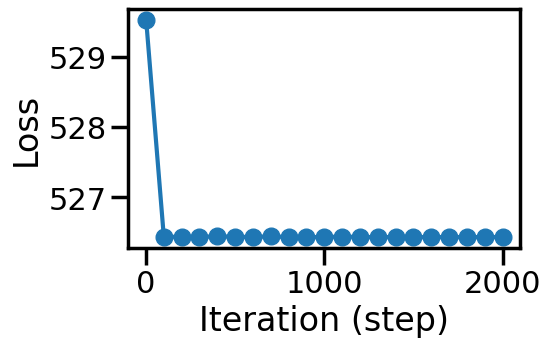

In [10]:
# Training curve
plt.figure(figsize=(6, 4))
plt.plot(np.asarray(steps_hist), np.asarray(loss_hist), marker='o')
plt.xlabel('Iteration (step)')
plt.ylabel('Loss')
# plt.title('Training loss vs iteration')
plt.tight_layout()
plt.show()


X_full: torch.Size([6, 100000, 11])


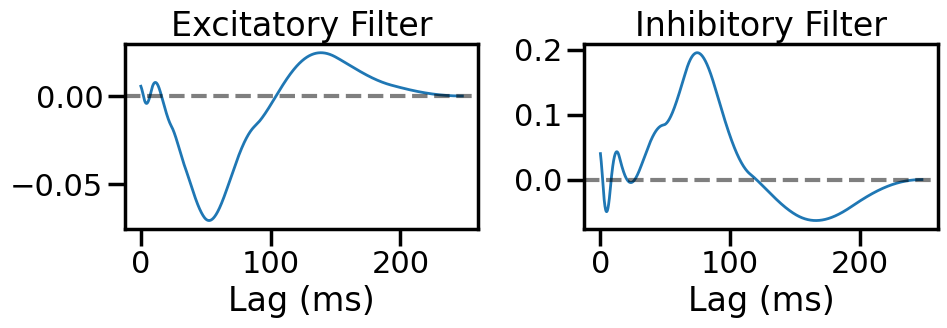

{'r2_cbem_full': 0.8096570236611036, 'r2_cbem_lin': 0.6029461481103381, 'K_exc': tensor([5.5502e-03, 5.3557e-03, 5.1493e-03,  ..., 1.6624e-07, 7.0319e-08,
        1.5053e-08], dtype=torch.float64), 'K_inh': tensor([ 3.9964e-02,  3.8244e-02,  3.6427e-02,  ..., -1.1396e-06,
        -4.8207e-07, -1.0319e-07], dtype=torch.float64), 'rate_full': array([2.58065098, 2.58064688, 2.58063866, ..., 2.72348916, 2.72318491,
       2.72303278]), 'rate_lin': array([2.58377024, 2.58376719, 2.58376109, ..., 2.53553293, 2.53523289,
       2.53508287])}


In [20]:

results = evaluate_model(trained, cbem_lin, 
                   stimulus_test, 
                   B_orth_t, dt,
                   psth_hz_smooth)

print(results)